In [6]:
#كل المكتبات اللى بستخدمها فى المشروع

import os
import sys
import random
import copy
import warnings
import xml.etree.ElementTree as ET
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from scipy.signal import butter, filtfilt
import mne
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from sklearn.utils.class_weight import compute_class_weight
from sklearn.preprocessing import label_binarize
from sklearn.metrics import f1_score
from sklearn.metrics import roc_curve, auc, confusion_matrix, classification_report, accuracy_score
from imblearn.over_sampling import SMOTE

DATA READING

In [3]:
raw_path = r"D:\mesa_ecg_sleep_staging\data\raw"
#طباعه مساء الداتا وهل فى فولدر ولا لا
print("path:", raw_path)
print("is the folder exists?", os.path.exists(raw_path))
#لو المسار فيه حاجه يطبع اجمالى عدد الfolders
#يطبع بردو كل فولدر الملفات ال edf وال xml اللى فيه
if os.path.exists(raw_path):
    subjects = sorted([f for f in os.listdir(raw_path) if os.path.isdir(os.path.join(raw_path, f))])
    print("\nNumber of individuals present:", len(subjects))
    print("Folder names:", subjects)
    
    for subj in subjects:
        subj_path = os.path.join(raw_path, subj)
        files = os.listdir(subj_path)
        edf = [f for f in files if f.endswith('.edf')]
        xml = [f for f in files if f.endswith('.xml')]
        
        print(f"\n→ Folder {subj}:")
        print(f"   EDF files: {len(edf)} → {edf}")
        print(f"   XML files: {len(xml)} → {xml}")
else:
    print("The path does not exist! Check it.")

path: D:\mesa_ecg_sleep_staging\data\raw
is the folder exists? True

Number of individuals present: 10
Folder names: ['0001', '0002', '0006', '0010', '0012', '0014', '0016', '0021', '0027', '0028']

→ Folder 0001:
   EDF files: 1 → ['mesa-sleep-0001.edf']
   XML files: 1 → ['mesa-sleep-0001-nsrr.xml']

→ Folder 0002:
   EDF files: 1 → ['mesa-sleep-0002.edf']
   XML files: 1 → ['mesa-sleep-0002-nsrr.xml']

→ Folder 0006:
   EDF files: 1 → ['mesa-sleep-0006.edf']
   XML files: 1 → ['mesa-sleep-0006-nsrr.xml']

→ Folder 0010:
   EDF files: 1 → ['mesa-sleep-0010.edf']
   XML files: 1 → ['mesa-sleep-0010-nsrr.xml']

→ Folder 0012:
   EDF files: 1 → ['mesa-sleep-0012.edf']
   XML files: 1 → ['mesa-sleep-0012-nsrr.xml']

→ Folder 0014:
   EDF files: 1 → ['mesa-sleep-0014.edf']
   XML files: 1 → ['mesa-sleep-0014-nsrr.xml']

→ Folder 0016:
   EDF files: 1 → ['mesa-sleep-0016.edf']
   XML files: 1 → ['mesa-sleep-0016-nsrr.xml']

→ Folder 0021:
   EDF files: 1 → ['mesa-sleep-0021.edf']
   XML fi

In [4]:
#اطبع اسماء ال channels فى patient ما عشان اشوف السيجنالز الموجوده ايه
raw_path = r"D:\mesa_ecg_sleep_staging\data\raw"
subjects = [s for s in os.listdir(raw_path) if os.path.isdir(os.path.join(raw_path, s))]

if subjects:
    first_subj = subjects[0]
    edf_file = os.path.join(raw_path, first_subj, f"mesa-sleep-{first_subj}.edf")
    
    try:
    #تحميل رأس الملف بس (بدون البيانات)
        raw = mne.io.read_raw_edf(edf_file, preload=False, verbose=False)
        
        print(f"Channel Names for Subject {first_subj} ")
        for i, ch in enumerate(raw.ch_names):
            print(f"{i+1}. {ch}")
        
    except Exception as e:
        print(f"Could not read file: {e}")
else:
    print("No subjects found in the path!")

Channel Names for Subject 0001 
1. EKG
2. EOG-L
3. EOG-R
4. EMG
5. EEG1
6. EEG2
7. EEG3
8. Pres
9. Flow
10. Snore
11. Thor
12. Abdo
13. Leg
14. Therm
15. Pos
16. EKG_Off
17. EOG-L_Off
18. EOG-R_Off
19. EMG_Off
20. EEG1_Off
21. EEG2_Off
22. EEG3_Off
23. Pleth
24. OxStatus
25. SpO2
26. HR
27. DHR


LABELING OF ANOTTATIONS

In [5]:
raw_path = r"D:\mesa_ecg_sleep_staging\data\raw"
labels_path = r"D:\mesa_ecg_sleep_staging\data\labels"
#اجيب الpatients
if os.path.exists(raw_path):
    subjects = sorted([f for f in os.listdir(raw_path) if os.path.isdir(os.path.join(raw_path, f))])
else:
    subjects = []
    print("The raw data path does not exist! Check your path.")

#function of xml processing
def parse_mesa_xml_to_epochs(xml_file):

    tree = ET.parse(xml_file)
    root = tree.getroot()
    
    epochs_data = []

#احول ال stages to labels
    stage_mapping = {
        "Wake|0": 0,
        "Stage 1 sleep|1": 1,
        "Stage 2 sleep|2": 2,
        "Stage 3 sleep|3": 3,
        "REM sleep|4": 4
    }
    
    scored_events = root.find('ScoredEvents')
    if scored_events is not None:
        for event in scored_events.findall('ScoredEvent'):
            event_type_elem = event.find('EventType')
            event_type = event_type_elem.text if event_type_elem is not None else ""
            
            if event_type == "Stages|Stages":
                event_concept = event.find('EventConcept').text
                start_time = float(event.find('Start').text)
                duration = float(event.find('Duration').text)
                
                stage_code = stage_mapping.get(event_concept, -1)
                
                if stage_code != -1:
                    # تقسيم الـ Duration إلى Epochs كل منها 30 ثانية
                    num_epochs = int(duration / 30)
                    for i in range(num_epochs):
                        epochs_data.append({
                            'start_time': start_time + (i * 30),
                            'stage': stage_code
                        })
                        
    return pd.DataFrame(epochs_data)

#هخلى ال stages بارقام عشان يبقى اسهل بعد كدا احفظها فى csv file

stage_names = {0: "Wake", 1: "N1", 2: "N2", 3: "N3", 4: "REM"}

for subj in subjects:
    subj_path = os.path.join(raw_path, subj)
    xml_files = [f for f in os.listdir(subj_path) if f.endswith('.xml')]
    
    if not xml_files:
        continue
        
    xml_path = os.path.join(subj_path, xml_files[0])
    
    try:
        df_labels = parse_mesa_xml_to_epochs(xml_path)
        
        if not df_labels.empty:
            # حفظ الملف
            output_file = os.path.join(labels_path, f"{subj}_labels.csv")
            df_labels.to_csv(output_file, index=False)
            
            print(f"Subject: {subj}")
            print(f"Total Epochs: {len(df_labels)}")
            
# حساب تكرار كل stage
            counts = df_labels['stage'].value_counts().sort_index()
            
 # طباعة التفاصيل  
            summary_str = " | ".join([f"{stage_names[s]}: {counts.get(s, 0)}" for s in range(5)])
            print(f"Stages Summary -> {summary_str}")
            
        else:
            print(f"Skipped: No valid stages in {subj}")
            
    except Exception as e:
        print(f"Failed to process {subj}: {str(e)}")

print("\nLabel extraction complete. All files saved to disk.")

Subject: 0001
Total Epochs: 1361
Stages Summary -> Wake: 752 | N1: 135 | N2: 455 | N3: 19 | REM: 0
Subject: 0002
Total Epochs: 1138
Stages Summary -> Wake: 571 | N1: 49 | N2: 362 | N3: 156 | REM: 0
Subject: 0006
Total Epochs: 960
Stages Summary -> Wake: 364 | N1: 141 | N2: 380 | N3: 75 | REM: 0
Subject: 0010
Total Epochs: 1199
Stages Summary -> Wake: 980 | N1: 20 | N2: 126 | N3: 73 | REM: 0
Subject: 0012
Total Epochs: 1359
Stages Summary -> Wake: 882 | N1: 85 | N2: 376 | N3: 16 | REM: 0
Subject: 0014
Total Epochs: 1501
Stages Summary -> Wake: 836 | N1: 22 | N2: 381 | N3: 262 | REM: 0
Subject: 0016
Total Epochs: 977
Stages Summary -> Wake: 355 | N1: 72 | N2: 511 | N3: 39 | REM: 0
Subject: 0021
Total Epochs: 1002
Stages Summary -> Wake: 139 | N1: 218 | N2: 512 | N3: 133 | REM: 0
Subject: 0027
Total Epochs: 1010
Stages Summary -> Wake: 215 | N1: 130 | N2: 641 | N3: 24 | REM: 0
Subject: 0028
Total Epochs: 990
Stages Summary -> Wake: 475 | N1: 70 | N2: 373 | N3: 72 | REM: 0

Label extractio

PREPROCESSING & EPOCHING

In [9]:
raw_path = r"D:\mesa_ecg_sleep_staging\data\raw"
labels_path = r"D:\mesa_ecg_sleep_staging\data\labels" 
processed_path = r"D:\mesa_ecg_sleep_staging\data\processed_eog" 

os.makedirs(processed_path, exist_ok=True)

SAMPLING_RATE = 256
EPOCH_DURATION = 30
SAMPLES_PER_EPOCH = EPOCH_DURATION * SAMPLING_RATE
total_processed_epochs = 0

#bandpass filter function 0.3 to 30
def eog_bandpass_filter(data, lowcut=0.3, highcut=30.0, fs=256, order=4):
    nyq = 0.5 * fs
    low = lowcut / nyq
    high = highcut / nyq
    b, a = butter(order, [low, high], btype='band')
    y = filtfilt(b, a, data)
    return y

subjects = [s for s in os.listdir(raw_path) if os.path.isdir(os.path.join(raw_path, s))]
subjects.sort()
#loop بتاعه ال preprocess
for subj in subjects:
    edf_file = os.path.join(raw_path, subj, f"mesa-sleep-{subj}.edf")
    label_file = os.path.join(labels_path, f"{subj}_labels.csv")
    
    if not os.path.exists(edf_file) or not os.path.exists(label_file):
        continue

    try:
        # طباعة اسم المريض
        print(f"Processing {subj}")
        
#قراية ال eog left بس
        raw = mne.io.read_raw_edf(edf_file, preload=False, verbose=False)
        target_ch = "EOG-L" 
        
        if target_ch not in raw.ch_names:
         
            continue
            
        raw.load_data().pick_channels([target_ch])
        eog_data = raw.get_data()[0]
#bandpass
        eog_filtered = eog_bandpass_filter(eog_data, fs=SAMPLING_RATE)
#Z-score normalization 
        eog_norm = (eog_filtered - np.mean(eog_filtered)) / (np.std(eog_filtered) + 1e-8)
#epoching
        num_epochs_signal = len(eog_norm) // SAMPLES_PER_EPOCH
        eog_truncated = eog_norm[:num_epochs_signal * SAMPLES_PER_EPOCH]
        X = eog_truncated.reshape(num_epochs_signal, SAMPLES_PER_EPOCH)
        
#بشوف ال labels file عشان اطابق ال epoching هناك بال epoching بتاع الsignal
        df_labels = pd.read_csv(label_file)
        y = df_labels['stage'].values
        
        min_epochs = min(len(X), len(y))
        X = X[:min_epochs]
        y = y[:min_epochs]
        
        valid_idx = np.where((y >= 0) & (y <= 4))[0]
        X = X[valid_idx]
        y = y[valid_idx]
#save&print
        if len(y) > 0:
            save_file = os.path.join(processed_path, f"{subj}_processed_eog.npz")
            np.savez_compressed(save_file, X=X, y=y)
            
            print(f"  → {len(y)} epochs processed")
            total_processed_epochs += len(y)

    except Exception:
        continue

print("\nPREPROCESSING COMPLETED SUCCESSFULLY!")
print(f"Total processed epochs: {total_processed_epochs}")
print(f"Files saved in: {processed_path}")

Processing 0001
  → 1439 epochs processed
Processing 0002
  → 1319 epochs processed
Processing 0006
  → 1079 epochs processed
Processing 0010
  → 1199 epochs processed
Processing 0012
  → 1427 epochs processed
Processing 0014
  → 1679 epochs processed
Processing 0016
  → 1199 epochs processed
Processing 0021
  → 1079 epochs processed
Processing 0027
  → 1199 epochs processed
Processing 0028
  → 1139 epochs processed

PREPROCESSING COMPLETED SUCCESSFULLY!
Total processed epochs: 12758
Files saved in: D:\mesa_ecg_sleep_staging\data\processed_eog


VISUALIZING

Raw Signal Length: 8294144 samples
Processed File Loaded - Number of epochs: 1079

--- Raw vs Processed - Subject 0006 (First Epoch) ---
Metric       Raw Signal         Processed Signal   Diff
Mean         -0.000009          -0.002399          -0.002390
Std          0.000035           0.667366           0.667331
Min          -0.000065          -1.204099          -1.204034
Max          0.000244           4.882393           4.882149
Range        0.000309           6.086492          

First 15 values:
Sample  0 | Raw:  0.00001 | Processed: -0.08014 | Diff: -0.08014
Sample  1 | Raw:  0.00001 | Processed: -0.09835 | Diff: -0.09835
Sample  2 | Raw:  0.00001 | Processed: -0.11717 | Diff: -0.11717
Sample  3 | Raw:  0.00000 | Processed: -0.13701 | Diff: -0.13702
Sample  4 | Raw:  0.00000 | Processed: -0.15782 | Diff: -0.15782
Sample  5 | Raw:  0.00000 | Processed: -0.17868 | Diff: -0.17869
Sample  6 | Raw:  0.00000 | Processed: -0.19773 | Diff: -0.19774
Sample  7 | Raw:  0.00000 | Processed: -0

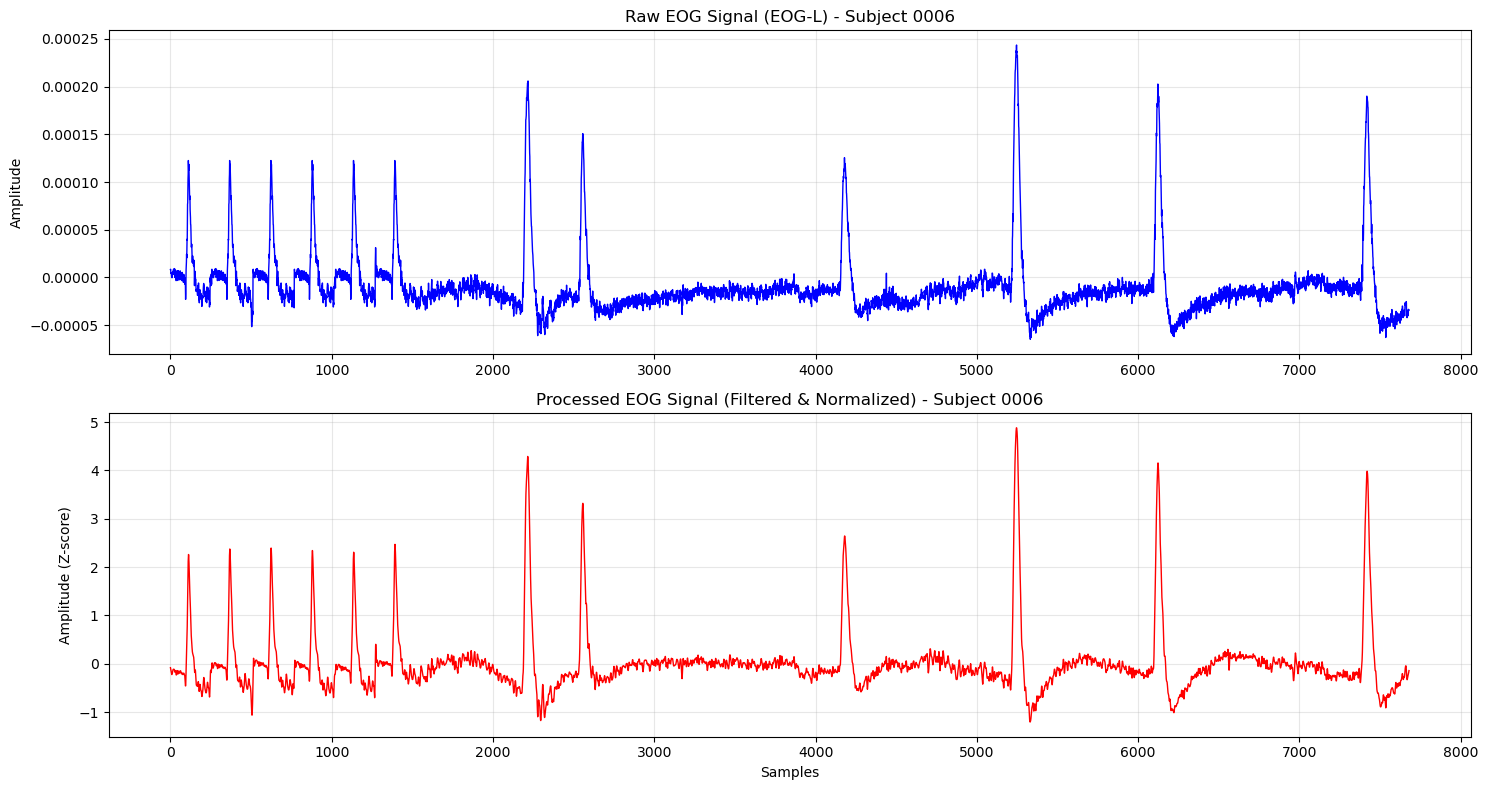

In [11]:
#طباعة الفرق قبل وبعد الpreprocess كل values و graph
subject = "0006"   

raw_path = r"D:\mesa_ecg_sleep_staging\data\raw"
processed_path = r"D:\mesa_ecg_sleep_staging\data\processed_eog"

SAMPLING_RATE = 256
EPOCH_DURATION = 30
SAMPLES_PER_EPOCH = EPOCH_DURATION * SAMPLING_RATE
#row data
edf_path = os.path.join(raw_path, subject, f"mesa-sleep-{subject}.edf")
#تحميل الداتا
raw = mne.io.read_raw_edf(edf_path, preload=False, verbose=False)
raw.load_data().pick_channels(["EOG-L"])
eog_raw = raw.get_data()[0]

print(f"Raw Signal Length: {len(eog_raw)} samples")
#قراية الداتا ال processed
processed_file = os.path.join(processed_path, f"{subject}_processed_eog.npz")
data = np.load(processed_file, allow_pickle=True)

X_processed = data['X']     
print(f"Processed File Loaded - Number of epochs: {X_processed.shape[0]}")
#اول epoch من الاتنين
epoch_processed = X_processed[0]   
epoch_raw = eog_raw[:SAMPLES_PER_EPOCH]
#طباعة الvalues
print(f"\n--- Raw vs Processed - Subject {subject} (First Epoch) ---")
print(f"{'Metric':<12} {'Raw Signal':<18} {'Processed Signal':<18} {'Diff'}")
print(f"{'Mean':<12} {np.mean(epoch_raw):<18.6f} {np.mean(epoch_processed):<18.6f} {np.mean(epoch_processed)-np.mean(epoch_raw):.6f}")
print(f"{'Std':<12} {np.std(epoch_raw):<18.6f} {np.std(epoch_processed):<18.6f} {np.std(epoch_processed)-np.std(epoch_raw):.6f}")
print(f"{'Min':<12} {np.min(epoch_raw):<18.6f} {np.min(epoch_processed):<18.6f} {np.min(epoch_processed)-np.min(epoch_raw):.6f}")
print(f"{'Max':<12} {np.max(epoch_raw):<18.6f} {np.max(epoch_processed):<18.6f} {np.max(epoch_processed)-np.max(epoch_raw):.6f}")
print(f"{'Range':<12} {(np.max(epoch_raw)-np.min(epoch_raw)):<18.6f} {(np.max(epoch_processed)-np.min(epoch_processed)):<18.6f}")

print("\nFirst 15 values:")
for i in range(15):
    print(f"Sample {i:2d} | Raw: {epoch_raw[i]:8.5f} | Processed: {epoch_processed[i]:8.5f} | Diff: {epoch_processed[i]-epoch_raw[i]:8.5f}")

# رسم ال graphs
plt.figure(figsize=(15, 8)) # تقليل الارتفاع قليلاً ليكون مناسباً لجزئين

#raw
plt.subplot(2, 1, 1) 
plt.plot(epoch_raw, color='blue', linewidth=1)
plt.title(f'Raw EOG Signal (EOG-L) - Subject {subject}')
plt.ylabel('Amplitude')
plt.grid(True, alpha=0.3)

# processed
plt.subplot(2, 1, 2)
plt.plot(epoch_processed, color='red', linewidth=1)
plt.title(f'Processed EOG Signal (Filtered & Normalized) - Subject {subject}')
plt.xlabel('Samples')
plt.ylabel('Amplitude (Z-score)')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Data Preparation & Splitting subject wise

In [14]:
# setup paths
processed_path = r"D:\mesa_ecg_sleep_staging\data\processed_eog"
splited_path = r"D:\mesa_ecg_sleep_staging\data\splited_eog"

os.makedirs(splited_path, exist_ok=True)

# get all processed subject files
all_files = [f for f in os.listdir(processed_path) if f.endswith('.npz')]
all_files.sort() # sort before shuffling for reproducibility

# set seed and shuffle for subject wise split
random.seed(42)
random.shuffle(all_files)

total_subjects = len(all_files)
print(f"Total subjects found: {total_subjects}")

if total_subjects == 0:
    print("No files found. Please check the processed_path.")
    sys.exit(1)

# 70/15/15 split
train_split = int(total_subjects * 0.70)
val_split = int(total_subjects * 0.85) 

train_files = all_files[:train_split]
val_files = all_files[train_split:val_split]
test_files = all_files[val_split:]

print(f"Train subjects: {len(train_files)}")
print(f"Val subjects: {len(val_files)}")
print(f"Test subjects: {len(test_files)}\n")

def combine_data(file_list, split_name):
    print(f"Processing {split_name} set...")
    X_list, y_list = [], []
    
    for f in file_list:
        file_path = os.path.join(processed_path, f)
        data = np.load(file_path, allow_pickle=True)
        X_list.append(data['X'])
        y_list.append(data['y'])
    
    X_combined = np.concatenate(X_list, axis=0)
    y_combined = np.concatenate(y_list, axis=0)
    
    print(f"{split_name} shape: X={X_combined.shape}, y={y_combined.shape}")
    return X_combined, y_combined

# process and save the splits
X_train, y_train = combine_data(train_files, "train")
np.savez_compressed(os.path.join(splited_path, "train_data.npz"), X=X_train, y=y_train)

X_val, y_val = combine_data(val_files, "val")
np.savez_compressed(os.path.join(splited_path, "val_data.npz"), X=X_val, y=y_val)

X_test, y_test = combine_data(test_files, "test")
np.savez_compressed(os.path.join(splited_path, "test_data.npz"), X=X_test, y=y_test)

print("\nData splitting completed.")
print(f"Saved to: {splited_path}")

Total subjects found: 10
Train subjects: 7
Val subjects: 1
Test subjects: 2

Processing train set...
train shape: X=(8573, 7680), y=(8573,)
Processing val set...
val shape: X=(1427, 7680), y=(1427,)
Processing test set...
test shape: X=(2758, 7680), y=(2758,)

Data splitting completed.
Saved to: D:\mesa_ecg_sleep_staging\data\splited_eog


In [17]:
# Attention layer to focus on important features
class Attention(nn.Module):
    def __init__(self, hidden_dim):
        super(Attention, self).__init__()
        self.attn = nn.Linear(hidden_dim, 1)

    def forward(self, x):
        weights = self.attn(x)
        weights = F.softmax(weights, dim=1)
        context = torch.sum(weights * x, dim=1)
        return context

In [18]:
#Residual Block for Conv1D
class ResidualBlock(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size, stride, padding):
        super(ResidualBlock, self).__init__()
        #Main Path
        self.conv = nn.Conv1d(in_channels, out_channels, kernel_size, stride, padding)
        self.bn = nn.BatchNorm1d(out_channels)
        self.relu = nn.ReLU()
 # Shortcut Connection
        self.shortcut = nn.Sequential()
        if stride != 1 or in_channels != out_channels:
            self.shortcut = nn.Sequential(
                nn.Conv1d(in_channels, out_channels, kernel_size=1, stride=stride),
                nn.BatchNorm1d(out_channels)
            )

    def forward(self, x):
        out = self.bn(self.conv(x))
        
        res = self.shortcut(x)
        
        if out.shape[2] != res.shape[2]:
            res = F.interpolate(res, size=out.shape[2], mode='linear', align_corners=False)
            
        out = out + res
        
        return self.relu(out)


In [19]:
#المودل الاساسى (sleepclass)
class SleepClass(nn.Module):
    def __init__(self, num_classes=5, input_channels=1):
        super(SleepClass, self).__init__()
    # Residual Blocks 
        self.layer1 = ResidualBlock(input_channels, 32, 64, 8, 32)
        self.layer2 = ResidualBlock(32, 64, 16, 1, 8)
        self.layer3 = ResidualBlock(64, 128, 8, 1, 4)
    # Pooling لتقليل الأبعاد
        self.pool = nn.MaxPool1d(kernel_size=4, stride=4)
    # LSTM Bidirectional + Attention
        self.lstm = nn.LSTM(128, 64, batch_first=True, bidirectional=True)
        self.attention = Attention(128)
    # Classifier    
        self.fc = nn.Sequential(
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(64, num_classes)
        )
# Feature Extraction using Residual Blocks& Pooling
    def forward(self, x):
        x = self.pool(self.layer1(x))
        x = self.pool(self.layer2(x))
        x = self.pool(self.layer3(x))
        
        x = x.permute(0, 2, 1)
        x, _ = self.lstm(x)
        x = self.attention(x)
        
        return self.fc(x)

In [20]:
class SleepDataset(Dataset):
    def __init__(self, X, y, augment=False):
        self.X = X
        self.y = y
        self.augment = augment
        
    def __len__(self):
        return len(self.y)
#augmentation
#random noise & scaling
    def __getitem__(self, idx):
        x = self.X[idx].copy()
        if self.augment:
            if np.random.rand() > 0.5:
                x += np.random.normal(0, 0.01, x.shape)
            if np.random.rand() > 0.5:
                x *= np.random.uniform(0.9, 1.1)
        
        return torch.tensor(x, dtype=torch.float32), torch.tensor(self.y[idx], dtype=torch.long)

In [21]:
def get_dataloaders(splited_path, batch_size=32):
    train_path = os.path.join(splited_path, "train_data.npz")
    val_path = os.path.join(splited_path, "val_data.npz")
    test_path = os.path.join(splited_path, "test_data.npz")

 #تحميل الداتا
    train_data = np.load(train_path, allow_pickle=True)
    X_train, y_train = train_data['X'], train_data['y']
    
    val_data = np.load(val_path, allow_pickle=True)
    X_val, y_val = val_data['X'], val_data['y']
    
    test_data = np.load(test_path, allow_pickle=True)
    X_test, y_test = test_data['X'], test_data['y']

    print(f" data before SMOTE: {X_train.shape}")
#SMOTE for train data عشان عدم توازن الداتا
    original_shape = X_train.shape
    X_train_2d = X_train.reshape(X_train.shape[0], -1) 
    
    smote = SMOTE(random_state=42)
    X_train_resampled, y_train_resampled = smote.fit_resample(X_train_2d, y_train)
    
    if len(original_shape) == 2:
        X_train_resampled = np.expand_dims(X_train_resampled, axis=1)
    else:
        X_train_resampled = X_train_resampled.reshape(X_train_resampled.shape[0], original_shape[1], original_shape[2])
    
    if len(X_val.shape) == 2: X_val = np.expand_dims(X_val, axis=1)
    if len(X_test.shape) == 2: X_test = np.expand_dims(X_test, axis=1)

    print(f"  data after SMOTE: {X_train_resampled.shape}")

    train_dataset = SleepDataset(X_train_resampled, y_train_resampled, augment=True)
    val_dataset = SleepDataset(X_val, y_val, augment=False)
    test_dataset = SleepDataset(X_test, y_test, augment=False)

    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, drop_last=True)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)
    
    return train_loader, val_loader, test_loader

In [22]:
#التجهيز للتدريب
epochs = 50
splited_path = r"D:\mesa_ecg_sleep_staging\data\splited_eog"

train_loader, val_loader, test_loader = get_dataloaders(splited_path, batch_size=32)

print(f"Data is ready! Train batches: {len(train_loader)}")

 data before SMOTE: (8930, 7680)
  data after SMOTE: (19490, 1, 7680)
Data is ready! Train batches: 609


In [24]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = SleepClass(num_classes=5).to(device)
#smoothing with loss fun for overfitting
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

optimizer = optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-3)
# Learning Rate Scheduler
scheduler = optim.lr_scheduler.OneCycleLR(
    optimizer, 
    max_lr=1e-3, 
    epochs=epochs,
    steps_per_epoch=len(train_loader)
)

In [21]:
#train & validation loop
for epoch in range(epochs):
    #train part
    model.train()
    train_loss, correct_train, total_train = 0.0, 0, 0
    
    train_bar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs} [Train]")
    for inputs, labels in train_bar:
        inputs, labels = inputs.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        scheduler.step() 
        
        train_loss += loss.item() * inputs.size(0)
        _, preds = torch.max(outputs, 1)
        correct_train += torch.sum(preds == labels.data)
        total_train += labels.size(0)
        
        train_bar.set_postfix({'Loss': loss.item(), 'LR': optimizer.param_groups[0]['lr']})
        
    epoch_train_loss = train_loss / total_train
    epoch_train_acc = correct_train.double() / total_train
#validation part
    model.eval()
    val_loss, correct_val, total_val = 0.0, 0, 0
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            
            val_loss += loss.item() * inputs.size(0)
            _, preds = torch.max(outputs, 1)
            correct_val += torch.sum(preds == labels.data)
            total_val += labels.size(0)
            
    epoch_val_loss = val_loss / total_val
    epoch_val_acc = correct_val.double() / total_val
    
#save of data for ghraphs
    train_losses.append(epoch_train_loss)
    val_losses.append(epoch_val_loss)
    train_accuracies.append(epoch_train_acc.item())
    val_accuracies.append(epoch_val_acc.item())
    
    print(f"Train Loss: {epoch_train_loss:.4f} | Train Acc: {epoch_train_acc:.4f} | Val Loss: {epoch_val_loss:.4f} | Val Acc: {epoch_val_acc:.4f}")
    
    # حفظ أفضل model
    if epoch_val_loss < best_val_loss:
        best_val_loss = epoch_val_loss
        best_model_weights = copy.deepcopy(model.state_dict())
        torch.save(best_model_weights, 'best_sleep_model.pth')

print("Training completed!")


Epoch 1/50 [Train]: 100%|██████████| 609/609 [00:54<00:00, 11.27it/s, Loss=1.44, LR=5.05e-5]


Train Loss: 1.4657 | Train Acc: 0.3659 | Val Loss: 1.2096 | Val Acc: 0.5580


Epoch 2/50 [Train]: 100%|██████████| 609/609 [00:53<00:00, 11.41it/s, Loss=0.905, LR=8.15e-5]


Train Loss: 1.2268 | Train Acc: 0.5423 | Val Loss: 0.9780 | Val Acc: 0.6944


Epoch 3/50 [Train]: 100%|██████████| 609/609 [00:53<00:00, 11.42it/s, Loss=0.812, LR=0.000132]


...

Train Loss: 0.4396 | Train Acc: 0.9946 | Val Loss: 0.8303 | Val Acc: 0.8229


Epoch 49/50 [Train]: 100%|██████████| 609/609 [00:51<00:00, 11.74it/s, Loss=0.435, LR=2.01e-6]


Train Loss: 0.4378 | Train Acc: 0.9949 | Val Loss: 0.8523 | Val Acc: 0.8130


Epoch 50/50 [Train]: 100%|██████████| 609/609 [00:53<00:00, 11.42it/s, Loss=0.436, LR=4.01e-9]


Train Loss: 0.4384 | Train Acc: 0.9948 | Val Loss: 0.9230 | Val Acc: 0.7915
Training completed!


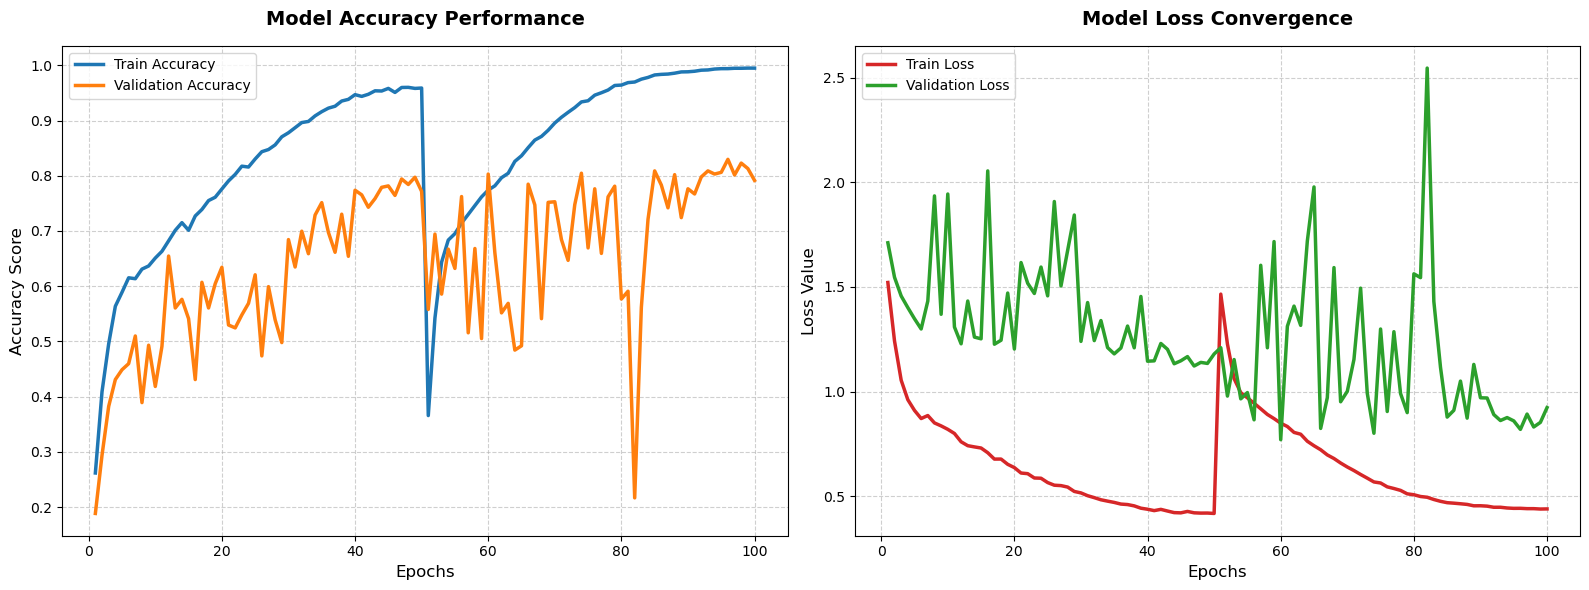

In [22]:
plt.style.use('seaborn-v0_8-muted') 
if 'train_losses' in locals() and len(train_losses) > 0:
    plt.figure(figsize=(16, 6))
    epochs_range = range(1, len(train_losses) + 1)
#accurcy curve
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, train_accuracies, label='Train Accuracy', color='#1f77b4', linewidth=2.5)
    plt.plot(epochs_range, val_accuracies, label='Validation Accuracy', color='#ff7f0e', linewidth=2.5)
    
    
    
    plt.title('Model Accuracy Performance', fontsize=14, fontweight='bold', pad=15)
    plt.xlabel('Epochs', fontsize=12)
    plt.ylabel('Accuracy Score', fontsize=12)
    plt.legend(frameon=True, fontsize=10)
    plt.grid(True, linestyle='--', alpha=0.6)

    #loss curve
    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, train_losses, label='Train Loss', color='#d62728', linewidth=2.5)
    plt.plot(epochs_range, val_losses, label='Validation Loss', color='#2ca02c', linewidth=2.5)
    
    
    plt.title('Model Loss Convergence', fontsize=14, fontweight='bold', pad=15)
    plt.xlabel('Epochs', fontsize=12)
    plt.ylabel('Loss Value', fontsize=12)
    plt.legend(frameon=True, fontsize=10)
    plt.grid(True, linestyle='--', alpha=0.6)

    plt.tight_layout()
    plt.show()


In [23]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = SleepClass(num_classes=5).to(device)

model.load_state_dict(torch.load('best_sleep_model.pth'))
model.eval()

all_preds = []
all_labels = []
all_probs = [] 

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        
        outputs = model(inputs)
        
        probs = F.softmax(outputs, dim=1)
        
        _, preds = torch.max(outputs, 1)
        
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())

all_labels = np.array(all_labels)
all_preds = np.array(all_preds)
all_probs = np.array(all_probs)

test_accuracy = accuracy_score(all_labels, all_preds)

print(f"Final Test Accuracy: {test_accuracy * 100:.2f}%")

Final Test Accuracy: 80.25%


In [24]:
#classification report
target_names = ['Wake', 'N1', 'N2', 'N3', 'REM']

print("Classification Report:\n")
print(classification_report(all_labels, all_preds, target_names=target_names, digits=4))

Classification Report:

              precision    recall  f1-score   support

        Wake     0.9805    0.9031    0.9402       836
          N1     0.3697    0.5532    0.4432       141
          N2     0.8627    0.7217    0.7859       618
          N3     0.5686    0.8923    0.6946       130
         REM     0.6651    0.7460    0.7032       189

    accuracy                         0.8025      1914
   macro avg     0.6893    0.7633    0.7134      1914
weighted avg     0.8383    0.8025    0.8137      1914



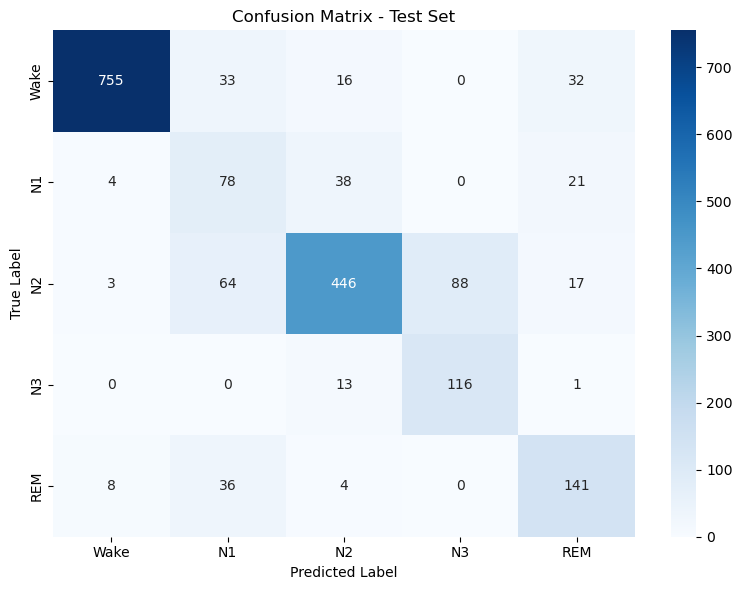

In [25]:
#confuson matrix
target_names = ['Wake', 'N1', 'N2', 'N3', 'REM']
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=target_names, yticklabels=target_names)
plt.title('Confusion Matrix - Test Set')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()

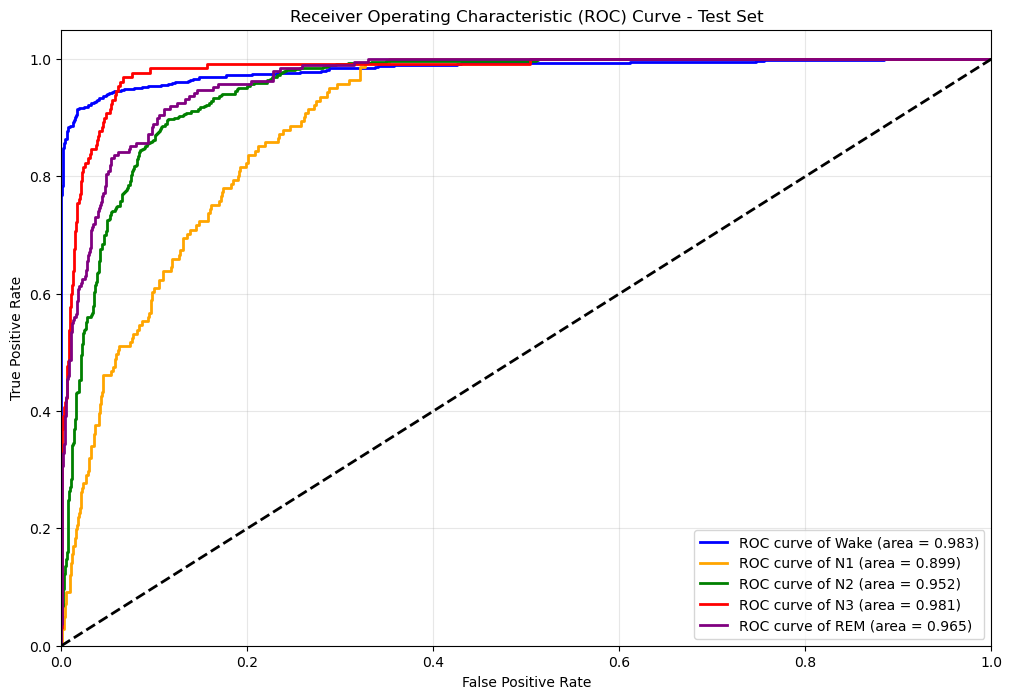

In [26]:
#roc curve
target_names = ['Wake', 'N1', 'N2', 'N3', 'REM']
n_classes = len(target_names)

y_test_binarized = label_binarize(all_labels, classes=[0, 1, 2, 3, 4])

plt.figure(figsize=(12, 8))
colors = ['blue', 'orange', 'green', 'red', 'purple']

# curve for each stage
for i in range(n_classes):
    fpr, tpr, _ = roc_curve(y_test_binarized[:, i], all_probs[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, color=colors[i], lw=2,
             label=f'ROC curve of {target_names[i]} (area = {roc_auc:.3f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2)

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve - Test Set')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()